In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import scanpy as sc

import os

import seaborn as sns



# Load Data

## Load entropy results

In [2]:
# Load Entropy value for each barcode on atac (if any barcode has invalid entropy value, it's not included in the file)
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDNAdebrisflag_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,log10_Entropy
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,-2.285327
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,-0.690589


In [3]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['invalid_entropy'] = union_cell_info['Entropy'].isna()
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,invalid_entropy
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,False
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,False


In [4]:
union_cell_info['Entropy'].isna().sum()

np.int64(22)

## Given some barcodes could have invalid entropy and does not have a record -- load fragment file 

In [5]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']



In [6]:
union_cell_info.groupby(['invalid_entropy', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)

_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
invalid_entropy,,,,
False,1865,81,236,180
True,0,13,0,9


In [7]:
union_cell_info.groupby(['DNA_debris', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)

_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
DNA_debris,,,,
NO,1865,72,236,189
YES,0,22,0,0


In [8]:
total_frag_per_bc = frag.groupby('atac_bc').size()

-----------------------------------------
------  DNA debris 	 Not DNA debris
Mean:   1006448.41 	  9250.3
Median: 920760.00 	  6154.0


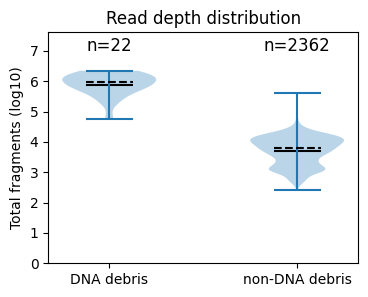

In [9]:
fig, ax = plt.subplots(figsize=(4,3))


read_depth_list = [total_frag_per_bc.loc[union_cell_info[union_cell_info['DNA_debris'] == 'YES'].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['DNA_debris'] == 'NO'].index]]
total_counts = [len(a) for a in read_depth_list]
x_pos = [0, 1]

v1 = ax.violinplot([np.log10(a + 1) for a in read_depth_list], positions=x_pos, showmeans=True, showmedians=True)


v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_pos)
ax.set_xticklabels(['DNA debris', 'non-DNA debris'])
ax.set_ylabel('Total fragments (log10)')
ax.set_title('Read depth distribution')
ax.set_ylim(0, np.log10(total_frag_per_bc.max()+ 1) * 1.2)

for i, count in enumerate(total_counts):
    ax.text(x_pos[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  DNA debris \t Not DNA debris")
print(f"Mean:   {mean_read_depth[0]:.2f} \t  {mean_read_depth[1]:.1f}")
print(f"Median: {median_read_depth[0]:.2f} \t  {median_read_depth[1]:.1f}")

2
3
4
-----------------------------------------
------  invalid entropy 	 DNA debris 	 ATAC pass entropy 	 ATAC pass CR 	 ATAC pass archr TSS
Mean:   	2.95 	 	 5.9 	 	 3.8 	 	 3.9 		  3.8
Median: 	2.87 	 	 6.0 	 	 3.9 	 	 3.9 		  3.8


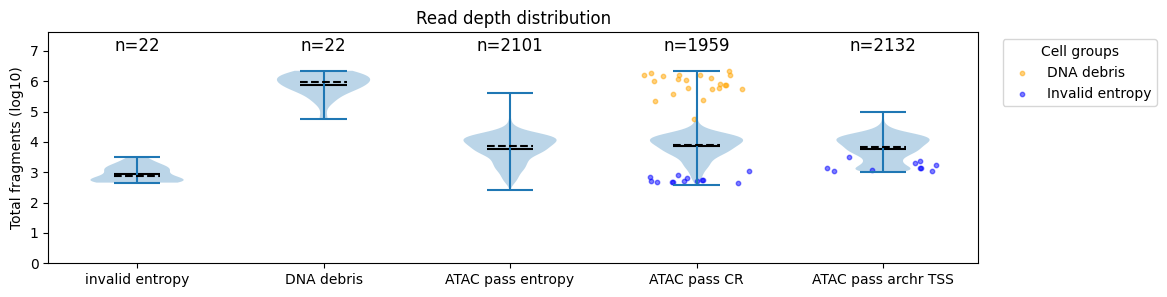

In [18]:
# Add dots to the violin plot with jitter
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):

    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    return ax.scatter(x_jittered, data_group, color=color, alpha=0.5, s=10) # s controls point size



fig, ax = plt.subplots(figsize=(12,3))
np.random.seed(999) # for reproducibility of jittered points


read_depth_list = [total_frag_per_bc.loc[union_cell_info[union_cell_info['invalid_entropy'] == True].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['DNA_debris'] == 'YES'].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['atac_pass_entropy'] == True].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['atac_pass_CR'] == True].index], 
                     total_frag_per_bc.loc[union_cell_info[union_cell_info['atac_pass_archr_TSS'] == True].index]]
read_depth_list = [np.log10(a + 1) for a in read_depth_list]
total_counts = [len(a) for a in read_depth_list]
x_pos = np.arange(len(read_depth_list))

v1 = ax.violinplot(read_depth_list, positions=x_pos, showmeans=True, showmedians=True)


v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_pos)
ax.set_xticklabels(['invalid entropy', 'DNA debris', 'ATAC pass entropy', 'ATAC pass CR', 'ATAC pass archr TSS'], rotation=0, ha='center')
ax.set_ylabel('Total fragments (log10)')
ax.set_title('Read depth distribution')
ax.set_ylim(0, np.log10(total_frag_per_bc.max()+ 1) * 1.2)

for i, count in enumerate(total_counts):
    ax.text(x_pos[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)



DNA_debris_cells = union_cell_info[union_cell_info['DNA_debris'] == 'YES'].copy()
DNA_debris_readdepth_values = [total_frag_per_bc.loc[DNA_debris_cells[DNA_debris_cells['atac_pass_entropy'] == True].index],
                                total_frag_per_bc.loc[DNA_debris_cells[DNA_debris_cells['atac_pass_CR'] == True].index],  
                                  total_frag_per_bc.loc[DNA_debris_cells[DNA_debris_cells['atac_pass_archr_TSS'] == True].index]]
DNA_debris_readdepth_values = [np.log10(a + 1) for a in DNA_debris_readdepth_values]
for group_data, i in zip(DNA_debris_readdepth_values, [2, 3, 4]):
    print(i)
    s1 = add_jittered_points(ax, group_data, i, color='orange')

Invalid_entropy_cells = union_cell_info[union_cell_info['invalid_entropy'] == True].copy()
Invalid_entropy_readdepth_values = [ total_frag_per_bc.loc[Invalid_entropy_cells[Invalid_entropy_cells['atac_pass_entropy'] == True].index], 
                                  total_frag_per_bc.loc[Invalid_entropy_cells[Invalid_entropy_cells['atac_pass_CR'] == True].index],
                                  total_frag_per_bc.loc[Invalid_entropy_cells[Invalid_entropy_cells['atac_pass_archr_TSS'] == True].index]]
Invalid_entropy_readdepth_values = [np.log10(a + 1) for a in Invalid_entropy_readdepth_values]
for group_data, i in zip(Invalid_entropy_readdepth_values, [2, 3, 4]):
    s2 = add_jittered_points(ax, group_data, i, color='blue')

ax.legend([s1, s2], ['DNA debris', 'Invalid entropy'], loc='upper right', bbox_to_anchor=(1.2, 1), title='Cell groups')


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  invalid entropy \t DNA debris \t ATAC pass entropy \t ATAC pass CR \t ATAC pass archr TSS")
print(f"Mean:   \t{mean_read_depth[0]:.2f} \t \t {mean_read_depth[1]:.1f} \t \t {mean_read_depth[2]:.1f} \t \t {mean_read_depth[3]:.1f} \t\t  {mean_read_depth[4]:.1f}")
print(f"Median: \t{median_read_depth[0]:.2f} \t \t {median_read_depth[1]:.1f} \t \t {median_read_depth[2]:.1f} \t \t {median_read_depth[3]:.1f} \t\t  {median_read_depth[4]:.1f}")

-----------------------------------------
------   common 	 ATAC pass entropy 	 ATAC pass archr TSS
Mean:    	 3.1 	 	 3.8 		  3.1
Median:  	 2.9 	 	 3.9 		  3.1


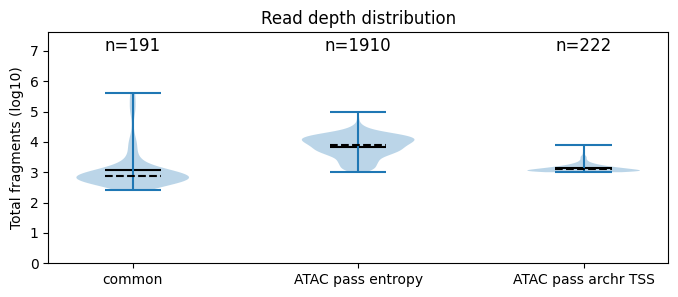

In [19]:
fig, ax = plt.subplots(figsize=(8,3))


read_depth_list = [
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['_2set_identified_by_atac_ST'] == 'entropy_only'].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['_2set_identified_by_atac_ST'] == 'both'].index], 
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['_2set_identified_by_atac_ST'] == 'tss_only'].index]]
read_depth_list = [np.log10(a + 1) for a in read_depth_list]
total_counts = [len(a) for a in read_depth_list]
x_pos = np.arange(len(read_depth_list))

v1 = ax.violinplot(read_depth_list, positions=x_pos, showmeans=True, showmedians=True)


v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_pos)
ax.set_xticklabels([ 'common', 'ATAC pass entropy',  'ATAC pass archr TSS'], rotation=0, ha='center')
ax.set_ylabel('Total fragments (log10)')
ax.set_title('Read depth distribution')
ax.set_ylim(0, np.log10(total_frag_per_bc.max()+ 1) * 1.2)

for i, count in enumerate(total_counts):
    ax.text(x_pos[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)



mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------   common \t ATAC pass entropy \t ATAC pass archr TSS")
print(f"Mean:    \t {mean_read_depth[0]:.1f} \t \t {mean_read_depth[1]:.1f} \t\t  {mean_read_depth[2]:.1f}")
print(f"Median:  \t {median_read_depth[0]:.1f} \t \t {median_read_depth[1]:.1f} \t\t  {median_read_depth[2]:.1f}")

-----------------------------------------
------  invalid entropy 	 Valid entropy
Mean:   1072.14 	  18614.6
Median: 740.50 	  6327.0


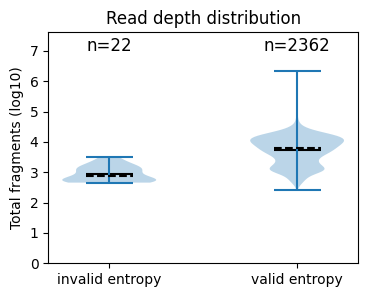

In [10]:
fig, ax = plt.subplots(figsize=(4,3))


read_depth_list = [total_frag_per_bc.loc[union_cell_info[union_cell_info['invalid_entropy'] == True].index],
                   total_frag_per_bc.loc[union_cell_info[union_cell_info['invalid_entropy'] == False].index]]
total_counts = [len(a) for a in read_depth_list]
x_pos = [0, 1]

v1 = ax.violinplot([np.log10(a + 1) for a in read_depth_list], positions=x_pos, showmeans=True, showmedians=True)


v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_pos)
ax.set_xticklabels(['invalid entropy', 'valid entropy'])
ax.set_ylabel('Total fragments (log10)')
ax.set_title('Read depth distribution')
ax.set_ylim(0, np.log10(total_frag_per_bc.max()+ 1) * 1.2)

for i, count in enumerate(total_counts):
    ax.text(x_pos[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  invalid entropy \t Valid entropy")
print(f"Mean:   {mean_read_depth[0]:.2f} \t  {mean_read_depth[1]:.1f}")
print(f"Median: {median_read_depth[0]:.2f} \t  {median_read_depth[1]:.1f}")

# Check P_closed_states

In [23]:
entropy_df['atac_bc'] = entropy_df.index.str.split('-1').str[0]
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,log10_Entropy,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,-2.285327,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,-0.690589,GAACAATGTCGGTTAT


In [24]:
union_cell_info['P_closed_state'] = union_cell_info.index.map(entropy_df.set_index('atac_bc')['P_closed_state'])

In [25]:
union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'entropy_only', 'P_closed_state']

atac_bc
AAACCGCCAGAAACCC    0.985494
AACCCGGCAGTGCCTC    0.985139
AACCTTTAGGTAAGTC    0.991752
AAGCTAATCAGGAGCC    0.989284
AAGGAACCACTTGCTG    0.974806
                      ...   
TTGCTTCTCGCTTCTT    0.992337
TTGTCATAGGCGCATA    0.989752
TTTAGGCGTGTTACTA    0.992153
TTTCAAGGTATGTTGC    0.966411
TTTGCTCTCATAACCT    0.957825
Name: P_closed_state, Length: 191, dtype: float64

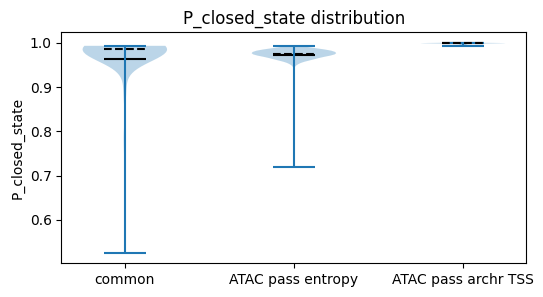

In [ ]:
fig, ax = plt.subplots(figsize=(6,3))

p_closed_state_list = [union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'entropy_only', 'P_closed_state'], 
                          union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'both', 'P_closed_state'],
                          union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'tss_only', 'P_closed_state'].fillna(1) 
]

x_pos = np.arange(len(p_closed_state_list))
v1 = ax.violinplot(p_closed_state_list, positions=x_pos, showmeans=True, showmedians=True)
ax.set_xticks(x_pos)
ax.set_xticklabels([ 'common', 'ATAC pass entropy',  'ATAC pass archr TSS'], rotation=0, ha='center')
ax.set_ylabel('P_closed_state')
ax.set_title('P_closed_state distribution')
v1['cmedians'].set_color('black')
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black')


In [45]:
union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'tss_only', 'P_closed_state'].describe()

count    212.000000
mean       0.998299
std        0.001603
min        0.993399
25%        0.998110
50%        0.998905
75%        0.999290
max        0.999854
Name: P_closed_state, dtype: float64

In [47]:
union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'both', 'P_closed_state'].describe()

count    1910.000000
mean        0.973115
std         0.015153
min         0.719761
25%         0.967858
50%         0.975048
75%         0.981421
max         0.993143
Name: P_closed_state, dtype: float64

In [28]:
bc_list = ['CCACAAACAACCTCGC', 'GCAAATATCCCTCGTC', 'TTCGCGCCATAGACTG']
union_cell_info.loc[union_cell_info.index.isin(bc_list)]

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,invalid_entropy,P_closed_state
atac_bc,,,,,,,,,,,,,
CCACAAACAACCTCGC,1054,False,False,True,none,tss_only,GGTACCGGTCAGGCAT,False,0.008509,4,NO,False,0.999287
GCAAATATCCCTCGTC,1043,False,False,True,none,tss_only,AGGATGCAGCATGTCG,False,0.009764,4,NO,False,0.999166
TTCGCGCCATAGACTG,1049,False,False,True,none,tss_only,GCTCATTGTGTTTGAG,False,0.007786,4,NO,False,0.999355


# Visualize fragment length distribution

In [12]:
bc_DNAdebris_list = union_cell_info.loc[union_cell_info['DNA_debris'] == 'YES'].index.tolist()
bc_invalid_entropy_list = union_cell_info.loc[union_cell_info['invalid_entropy']].index.tolist()
bc_entropy_only_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_SC'] == 'entropy_only'].index.tolist()
bc_cr_only_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_SC'] == 'cr_only'].index.tolist()
bc_common_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_SC'] == 'both'].index.tolist()

In [ ]:
individual_bc_frag_subdir = os.path.join(Union_cell_subdir, 'cmp_SC', 'individual_bc_frag')
if not os.path.exists(individual_bc_frag_subdir):
    os.makedirs(individual_bc_frag_subdir)

for l,n in zip([bc_DNAdebris_list, bc_invalid_entropy_list, bc_entropy_only_list, bc_cr_only_list, bc_common_list], 
             ['DNA_debris', 'invalid_entropy', 'entropy_only', 'cr_only', 'common']):
    bc_df = pd.DataFrame({'atac_BC': l})
    bc_df.to_csv(os.path.join(individual_bc_frag_subdir, f'{n}_bc_list.tsv'), sep='\t', index=True)

In [20]:
frag.head(2)

,chrom,start,end,support,atac_bc,frag_length
atac_BC,,,,,,
AGTAGGCGTCCATTAA-1,chr1,10067,10198,1,AGTAGGCGTCCATTAA,131
TGAGGCATCATCAGTT-1,chr1,10085,10333,3,TGAGGCATCATCAGTT,248


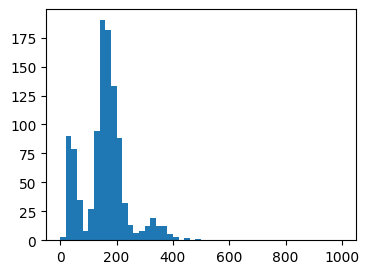

In [22]:
fig, ax = plt.subplots(figsize=(4,3))
a = frag.loc[frag['atac_bc'] == 'CCACAAACAACCTCGC', 'frag_length']
_ = ax.hist(a, bins=50, range=(0, 1000))

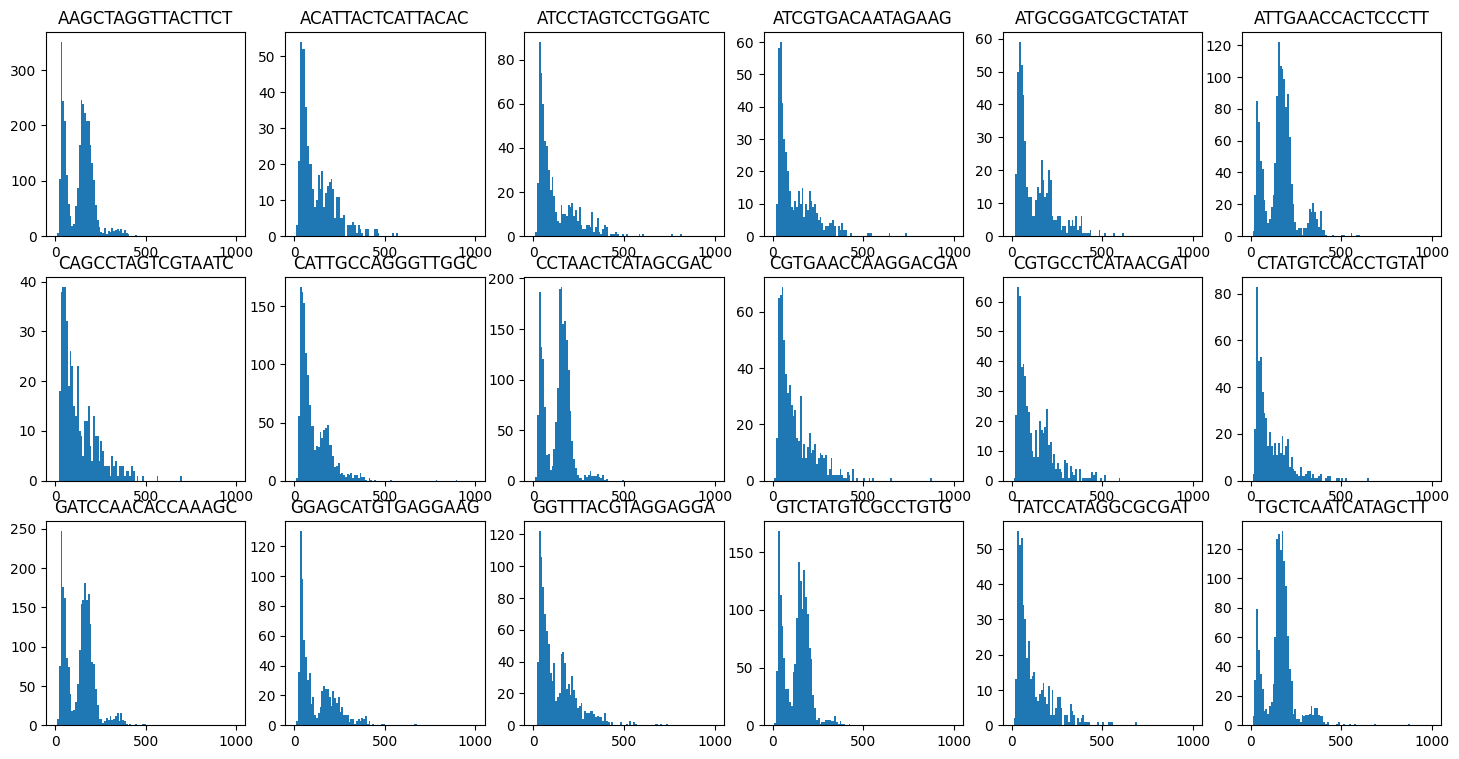

In [ ]:

ncol = 6
nrow = 3
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*3))
ax = ax.flatten()

for i, bc in enumerate(bc_invalid_entropy_list):
    if i >= nrow*ncol:
        break
    _ = ax[i].hist(frag.loc[frag['atac_bc'] == bc, 'frag_length'], bins=100, range=(0, 1000))
    ax[i].set_title(bc)

Text(0.5, 1.02, 'Fragment length distribution of DNA debris barcodes')

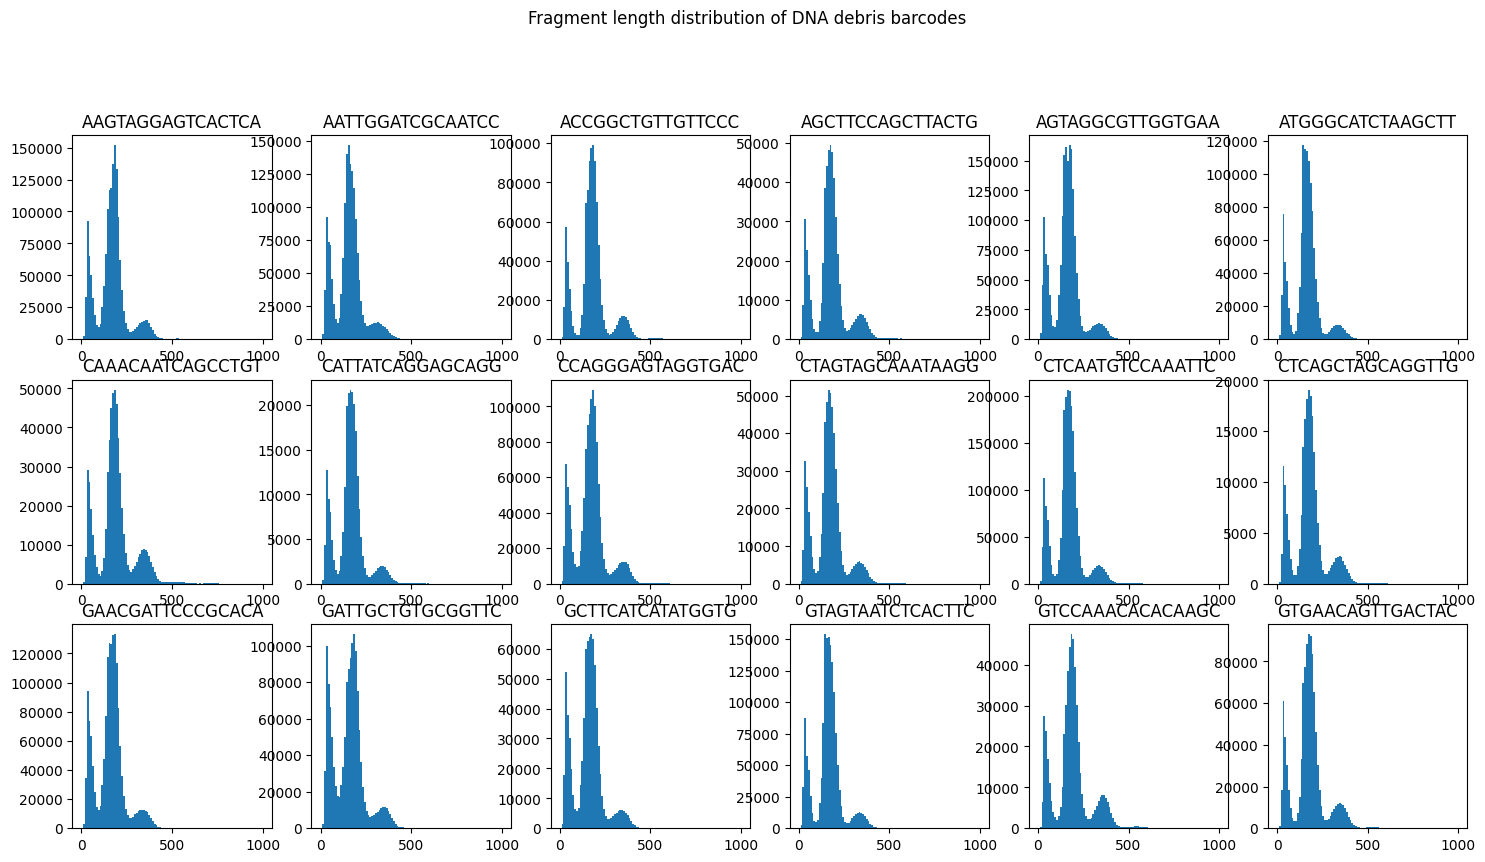

In [33]:
total_sub_fig = len(bc_DNAdebris_list)
ncol = 6
nrow = 3
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*3))
ax = ax.flatten()

for i, bc in enumerate(bc_DNAdebris_list):
    if i >= nrow*ncol:
        break
    _ = ax[i].hist(frag.loc[frag['atac_bc'] == bc, 'frag_length'], bins=100, range=(0, 1000))
    ax[i].set_title(bc)
fig.suptitle('Fragment length distribution of DNA debris barcodes', y=1.02)

In [14]:
bc_tss_list = union_cell_info.loc[union_cell_info['atac_pass_archr_TSS'] == True].index.tolist()
bc_cr_list = union_cell_info.loc[union_cell_info['atac_pass_CR'] == True].index.tolist()
bc_entropy_list = union_cell_info.loc[union_cell_info['atac_pass_entropy'] == True].index.tolist()

In [15]:
frag_tss = frag.loc[frag['atac_bc'].isin(bc_tss_list), 'frag_length']
frag_tss.shape

(18846874,)

In [21]:
frag_entropy = frag.loc[frag['atac_bc'].isin(bc_entropy_list), 'frag_length']
frag_entropy.shape

(21446286,)

Text(0.5, 1.0, 'Fragment length distribution of TSS-passing barcodes')

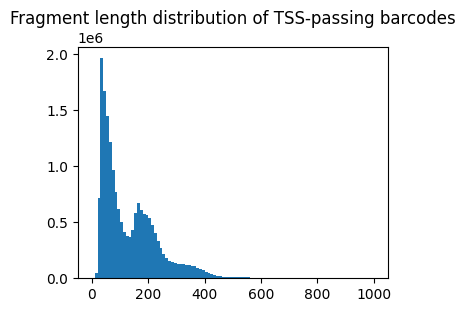

In [20]:
fig, ax = plt.subplots(figsize=(4,3))
_ = ax.hist(frag_tss, bins=100, range=(0, 1000))
ax.set_title('Fragment length distribution of TSS-passing barcodes')    

Text(0.5, 1.0, 'Fragment length distribution of entropy-passing barcodes')

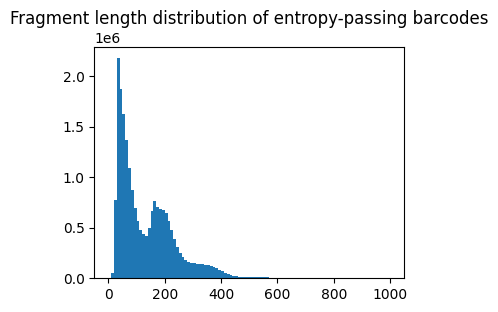

In [22]:
fig, ax = plt.subplots(figsize=(4,3))
_ = ax.hist(frag_entropy, bins=100, range=(0, 1000))
ax.set_title('Fragment length distribution of entropy-passing barcodes')

In [ ]:
tss_unique_bc_low_frip=['AAGCTAGGTTACTTCT'] # frip is about 4%
frag_example = frag.loc[frag['atac_bc'] == tss_unique_bc_low_frip[0], 'frag_length']

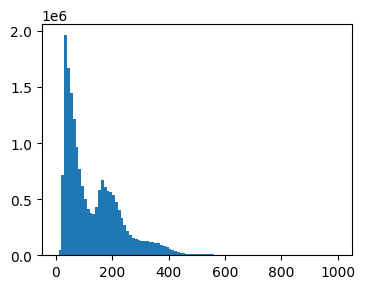

In [26]:
fig, ax = plt.subplots(figsize=(4,3))
_ = ax.hist(frag_tss, bins=100, range=(0, 1000))


# Compare ST (Sade v.s. TSS)

In [17]:
bc1_entropy_only_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'entropy_only'].index.tolist()
bc1_tss_only_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'tss_only'].index.tolist()
bc1_common_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_ST'] == 'both'].index.tolist()

In [22]:
frag1_entropy_only = frag.loc[frag['atac_bc'].isin(bc1_entropy_only_list), 'frag_length']
frag1_tss_only = frag.loc[frag['atac_bc'].isin(bc1_tss_only_list), 'frag_length']
frag1_common = frag.loc[frag['atac_bc'].isin(bc1_common_list), 'frag_length']

In [ ]:
frag1_entropy_only.shape, frag1_tss_only.shape, frag1_common.shape

((2917440,), (318028,), (18528846,))

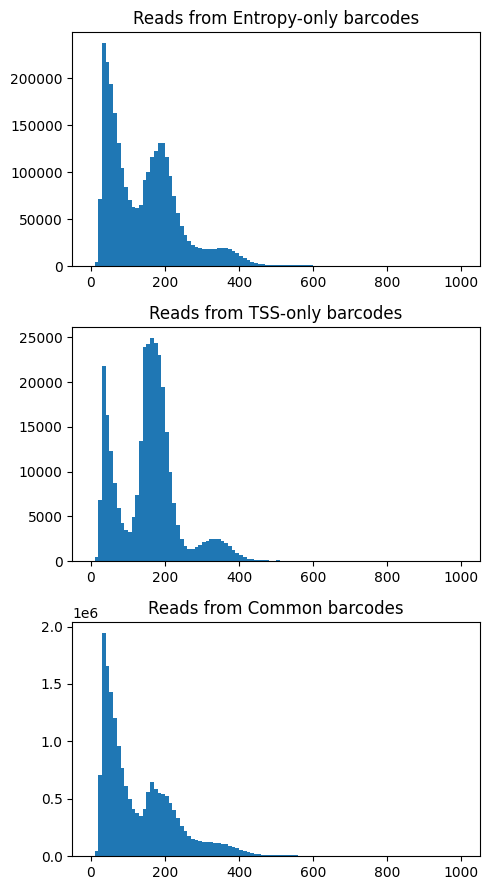

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(5, 9), sharex=True)

for ax, fg in zip(axes, [frag1_entropy_only, frag1_tss_only, frag1_common]):
    _ = ax.hist(fg, bins=100, range=(0, 1000))
    ax.tick_params(labelbottom=True)

axes[0].set_title('Reads from Entropy-only barcodes')
axes[1].set_title('Reads from TSS-only barcodes')
axes[2].set_title('Reads from Common barcodes')

fig.tight_layout()